# Setting libraries and functions

In [398]:
%matplotlib widget
import pybt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()


In [399]:
plt.close('all')

In [400]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import septa

In [401]:
p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


In [402]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # lose the particles on the blade
        particles.state[:n_part] = np.where((particles.x[:n_part]>self.blade_position) & (particles.x[:n_part]<(self.blade_position+self.thickness)) & (particles.state[:n_part]==1), -1, 1)

        # kick the particles beyond the blade
        if self.kick != 0:
            particles.px[:n_part] +=  np.where((particles.x[:n_part] > (self.blade_position+self.thickness)) & (particles.state[:n_part]==1), 1, 0) * self.kick

        return None


In [403]:
# install the 5 zs
def install_septa(line, install_zs=True, septum_aperture_size=68e-3):
    septa_names_with_apertures = []

    if install_zs:
        septum_names = ["zs.21633", "zs.21639", "zs.21655", "zs.21671", "zs.21676"]
        
        for septum_name in septum_names:
            zs = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=septum_aperture_size, thickness=0.3e-3, kick=0.440e-3 / 5
                ),
            )
            line.insert_element(septum_name + ".sep", zs, index=septum_name)
            septa_names_with_apertures.append(septum_name + ".sep")

        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=0
            ),
        )
        line.insert_element("tpst.21760_entry" + ".sep", zs, index="tpst.21760_entry")
        septa_names_with_apertures.append("tpst.21760_entry" + ".sep")


    for mst in ["mst.21774", "mst.21779", "mst.21794"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=1.69520713e-3 / 3
            ),
        )
        line.insert_element(mst + ".sep", zs, index=mst)
        septa_names_with_apertures.append(mst + ".sep")

    for mse in ["mse.21832", "mse.21837", "mse.21852", "mse.21857", "mse.21872"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=20e-3, kick=9.74519477e-3 / 5
            ),
        )
        line.insert_element(mse + ".sep", zs, index=mse)
        septa_names_with_apertures.append(mse + ".sep")

    septum = xt.LimitRect(min_x=-1.0, max_x=septum_aperture_size, min_y=-1.0, max_y=1.0)


    line.insert_element(
        name="tt20.extraction",
        element=xt.LimitRect(min_x=-1.0, max_x=70e-3, min_y=-1.0, max_y=1.0),
        index="ap.do.mse21872",
    )
    return septa_names_with_apertures


In [404]:
def draw_synoptic(ax, line, line_df):
    
    compound_names = line_df["name"].unique()
    for compound_name in compound_names:
        compound_df = line_df[line_df["name"] == compound_name]
        if compound_df["element_type"].isin(["Quadrupole"]).any():
            k1 = (
                compound_df[compound_df["element_type"] == "Quadrupole"]["element"]
                .squeeze()
                .k1
            )
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, 0), s2 - s1, np.sign(k1), facecolor="k", edgecolor="k"
                )
            )
        elif compound_df["element_type"].isin(["Sextupole", 'Bend', 'Multipole']).any():
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, -1), s2 - s1, 2, facecolor="k", edgecolor="k"
                )
            )

def plot_twiss(fig, twiss, line):

    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[1, 4, 4])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)     #UNUSED, IMPLEMENT TO HAVE THE VISUAL REPRESENTATION OF THE ENVELOPE THOUGH THE LATTICE

    plt.setp(ax2.get_xticklabels(), visible=False)

    # top plot is synoptic
    ax1.axis('off')
    ax1.set_ylim(-1.2, 1)
    ax1.plot([0, twiss['s'].max()], [0, 0], 'k-')


    #2nd plot is beta functions
    ax2.set_ylabel(r'Twiss (m)')
    ax2.plot(twiss['s'], twiss['betx'], 'r-', label=r'$\beta_x$')
    ax2.plot(twiss['s'], twiss['bety'], 'b-', label=r'$\beta_y$')
    ax2.plot(twiss['s'], twiss['dx']*10, 'g-', label=r'$D_x x10$')
    ax2.set_xlim(twiss['s'][0], twiss['s'][-1])
    ax2.legend(loc='upper right')

    line_df = line.to_pandas()
    line_df = line_df[(line_df['s'] >= twiss.s[0]) & (line_df['s'] <= twiss.s[-1])]

    draw_synoptic(ax1, line, line_df)
    
    axnames = ax1.twiny()
    axnames.spines['top'].set_visible(False)
    axnames.spines['left'].set_visible(False)
    axnames.spines['right'].set_visible(False)
    ax1.get_shared_x_axes()._grouper.join(ax1, axnames)
    
    ticks, ticks_labels = list(), list()
    
    for keyword in ['Quadrupole', 'Sextupole', 'Bend', 'Multipole']:
        sub_line = line_df[line_df['element_type'] == keyword]
        ticks += list(sub_line['s'])
        ticks_labels += list(sub_line['name'])

    axnames.set_xticks(ticks)
    axnames.set_xticklabels(ticks_labels, rotation=60)




# with ZS

In [405]:
line = xt.Line.from_json("./sps_with_extraction.json")
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.cycle("bpcn.20902_entry", inplace=True)


Loading line from dict:   0%|          | 0/9944 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9944 [00:00<?, ?it/s]

In [406]:
line.slice_thick_elements(
    slicing_strategies=[
        xt.Strategy(slicing=None),
        xt.Strategy(slicing=xt.Uniform(100), name='qf.21210'),
        xt.Strategy(slicing=xt.Uniform(100), name='qfa.21610'),
])

Slicing line:   0%|          | 0/9946 [00:00<?, ?it/s]

In [407]:
#line = xt.Line.from_json("./sps_with_extraction.json")
septa_names_with_apertures = install_septa(line)

#line.cycle("bpcn.20902_entry", inplace=True)

tw = line.twiss()
print(tw.qx, tw.qy, tw.dqx, tw.dqy)

n_part = 300
zeta = 0.0
x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)
dpp = np.random.rand(n_part) * DPP


particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
tw_lss2 = tw.rows['bpcn.20902_entry':'lsf.22005_entry']

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Ignoring collective elements in particles generation.


26.666947551980073 26.58002387096692 -35.416616418650904 14.480191059860203


In [408]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.loc['mbb.20950_exit':'qda.21910_exit']  
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    


In [409]:
bg = line.particle_ref._gamma0[0]*line.particle_ref._beta0[0]  #this line is calculating the relativistic quantity Beta Gamma for the reference particle in the line
sigma_x = lambda bet, d, n_sigma=1, bg=bg, dpp=DPP, eps=N_EX: np.sqrt(bet*eps/bg + (d*dpp)**2)*n_sigma  #computing the the BEAM SIZE at a given location

#place the element apertures relative to the circulating beam
distance_to_beam_at_first_zs_sigma = (line['zs.21633.sep'].interaction_process.blade_position - tw_lss2['x', 'zs.21633.sep'])/sigma_x(tw_lss2['betx', 'zs.21633.sep'], tw_lss2['dx', 'zs.21633.sep'])


# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'mst' in septum_name:
        sigma_margin = 2
    elif 'mse' in septum_name:
        sigma_margin = 5
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw_lss2['betx', septum_name], tw_lss2['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw_lss2['x', septum_name] + distance_to_beam

In [410]:
num_turns = 300
line.discard_tracker()
#line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto')) #Not working on MacOS
line.build_tracker(_context=xo.ContextCpu()) 


particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
line.time_last_track

29.716633646996343

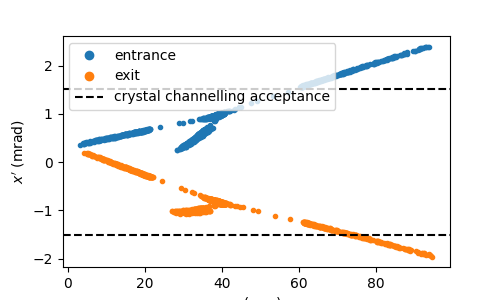

In [423]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))



for i, (target_s, label) in enumerate(zip([225.548 , 229.339],['entrance', 'exit'])):
    elem = tw_lss2_df.loc[(tw_lss2_df['s'] - target_s).abs().idxmin()]
    ax.plot(elem['monitors'].x*1e3, elem['monitors'].px*1e3, '.', color=plt.cm.tab10(i))
    ax.plot([], [], 'o', color=plt.cm.tab10(i), label=label)

ax.plot([], [], 'k--', label='crystal channelling acceptance')

ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

ax.axhline(-1.5-10e-3, color='k', ls='--')
ax.axhline(+1.5+10e-3, color='k', ls='--')


In [424]:
elem['monitors'].x

array([[0.01674476, 0.03282262, 0.07075089, 0.00549581, 0.02697421,
        0.09424492],
       [0.02129388, 0.03505293, 0.0622639 , 0.01503143, 0.0326061 ,
        0.0733432 ],
       [0.03712545, 0.04023776, 0.03875757, 0.03721746, 0.04026589,
        0.03864192],
       ...,
       [0.03762189, 0.0392341 , 0.03932101, 0.03762503, 0.03927731,
        0.03928524],
       [0.04025627, 0.03676126, 0.03919419, 0.04025738, 0.03672321,
        0.03922008],
       [0.03889257, 0.03971374, 0.03756445, 0.03893491, 0.03971494,
        0.03754525]], dtype=float32)

0 qfa.21610..40 53
1 qfa.21610..41 53
2 qfa.21610..42 53
3 qfa.21610..43 53
4 qfa.21610..44 53
5 qfa.21610..45 53
6 qfa.21610..46 53
7 qfa.21610..47 53
8 qfa.21610..48 53
9 qfa.21610..49 53
10 qfa.21610..50 53
11 qfa.21610..51 53
12 qfa.21610..52 53
13 qfa.21610..53 53
14 qfa.21610..54 53
15 qfa.21610..55 53
16 qfa.21610..56 53
17 qfa.21610..57 53
18 qfa.21610..58 53
19 qfa.21610..59 53
20 qfa.21610..60 53


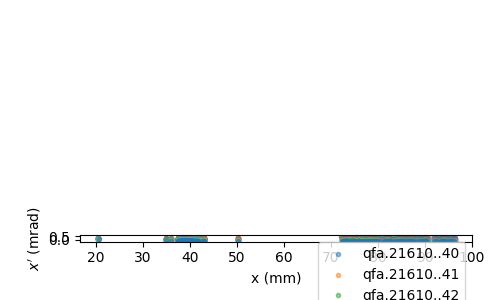

In [441]:
fig, ax = plt.subplots(1, 1, figsize=(5,3), tight_layout=True)

colors = plt.get_cmap('tab10').colors

for i, monitor_name in enumerate(tw_lss2_df.loc['qfa.21610..40':'qfa.21610..60'].index):
    elem = tw_lss2_df.loc[monitor_name]
    color = colors[i % len(colors)]  # Cycle through the palette
    ax.plot(elem['monitors'].x[:,5]*1e3, elem['monitors'].px[:,5]*1e3, '.', alpha=0.5, label=monitor_name,  color=color)
    print(i, monitor_name, len(elem))
    


# ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

ax.legend()

#ax.axhline(-1-10e-3, color='k', ls='--')
#ax.axhline(+1+10e-3, color='k', ls='--')
#ax.plot([], [], 'k--', label='crystal channelling acceptance')





In [434]:
elem['monitors'].x[:,0].shape

(300,)

/Users/matteogiacomelli/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self.figure.savefig(buf, format='png', dpi='figure')


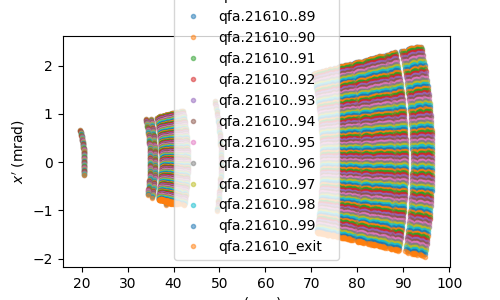

In [444]:
fig2, ax = plt.subplots(1, 1, figsize=(5, 3), tight_layout=True)

# Use drop_duplicates to remove redundancy and ensure unique monitors
unique_monitors_df = tw_lss2_df.loc['qfa.21610_entry':'qfa.21610_exit'].drop_duplicates(subset=['monitors'])

# Iterate through the unique monitors and plot their phase space
for monitor_name in unique_monitors_df.index:
    elem = unique_monitors_df.loc[monitor_name]
    ax.plot(elem['monitors'].x[:,5] * 1e3, elem['monitors'].px[:,5] * 1e3, '.', alpha=0.5, label=monitor_name)

# Set axis labels
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

# Add legend
ax.legend()

# Optionally add horizontal lines for reference (commented out by default)
# ax.axhline(-1-10e-3, color='k', ls='--')
# ax.axhline(+1+10e-3, color='k', ls='--')
# ax.plot([], [], 'k--', label='crystal channelling acceptance')

plt.show()


In [442]:
ax.fill_between([60, 100], 14e-3,34e-3, color='k', alpha=0.2)


In [ ]:
for monitor_name in tw_lss2_df.loc['qfa.21610_entry':'qfa.21610_exit'].index:
    elem = tw_lss2_df.loc[monitor_name]
    ax.plot(elem['monitors'].x*1e3, elem['monitors'].px*1e3, '.', alpha=0.5, label=monitor_name)

In [336]:
#for angle in [4, 14, 24]:
#    ax.fill_between([60, 100], (angle-10)*1e-3, (angle+10)*1e-3, color='k', alpha=0.2)


In [415]:
ta5bZS = line.get_table()

## tracking around the septa

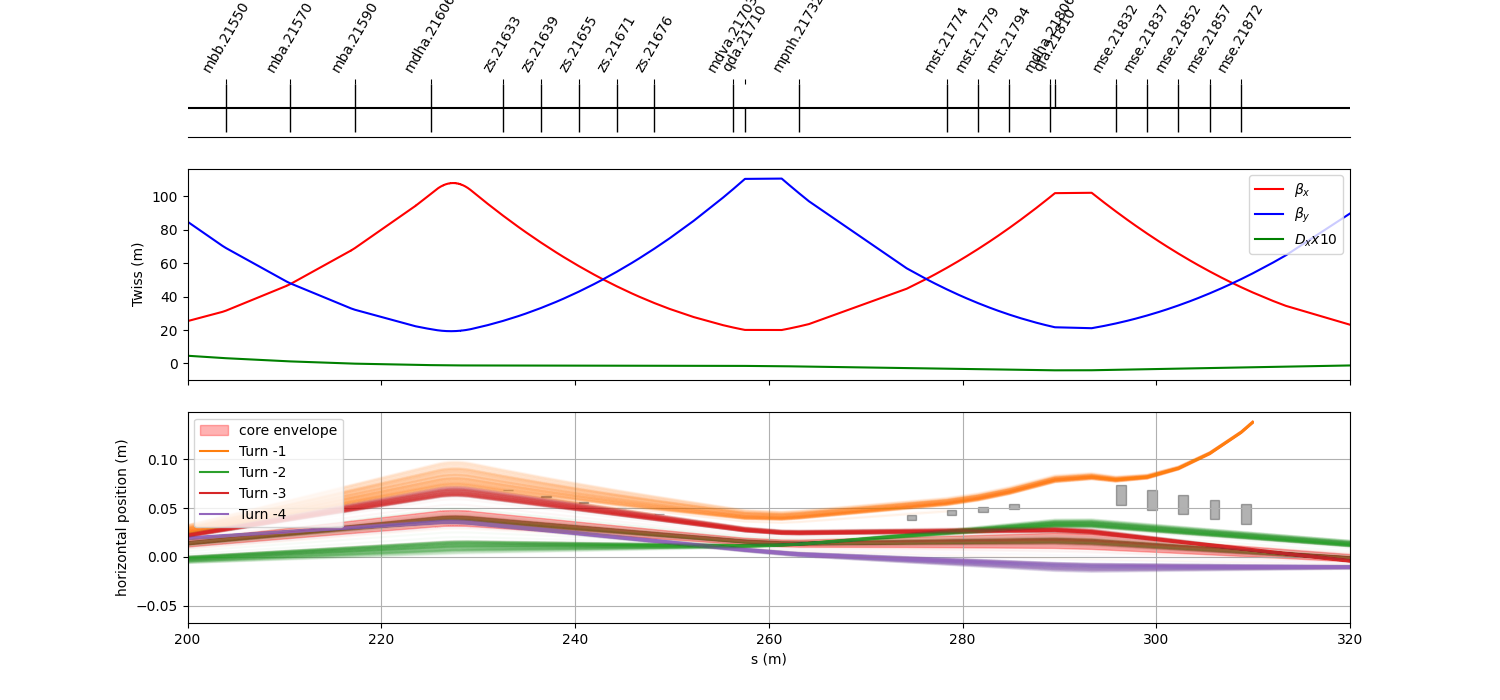

In [102]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlim(200, 320)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')



# ploting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
    
### PLOTTING TRAJECTORIES     
ax = fig.axes[2]
alpha = 10/particles._capacity
plot_only_lost = False
num_turns = 4

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in range(particles._capacity):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 20e-3].squeeze()
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend(loc = 'upper left')

In [103]:
# ax2.plot(tw_lss2_df['s'], (tw_lss2_df['mux']-tw_lss2_df.loc['tpst.21760_entry.sep']['mux'])*360, 'k--', label=r'$\Delta \mu_x$')
# ax2.legend

# ax2.axhline(0, color='k', ls='--', alpha=0.3)
# ax2.axhline(-90, color='k', ls='--', alpha=0.3)
# ax2.axhline(-270, color='k', ls='--', alpha=0.3)

tpst_row = tw_lss2_df.loc['tpst.21760_entry.sep']
# for loc in ['tecs.21602_entry', 'mdh.21207_exit']:
#     row = tw_lss2_df.loc[loc]
#     dphi = (row['mux']-tpst_row['mux'])
#     print(f"{loc:30s} {dphi*360:6.2f}deg and sin is {np.sin(dphi*np.pi):6.2f}")



# replacing ZS by crystal

## Cration of the line

In [386]:
n_part = 100

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP


In [387]:
# loading optics but thining the 2 quads in LSS2
line : xt.Line = xt.Line.from_json("sps_with_extraction_sliced_quads.json")
septa_names_with_apertures = install_septa(line, install_zs=False)
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)

line.cycle("bpcn.20902_entry", inplace=True)

""" 
line.slice_thick_elements(
    slicing_strategies=[
        xt.Strategy(slicing=None),
        xt.Strategy(slicing=xt.Uniform(4), name='qf.21210'),
        xt.Strategy(slicing=xt.Uniform(4), name='qfa.21610'),
])


class EverestCrystal(BaseCollimator):
    _xofields = { **BaseCollimator._xofields,
        'align_angle':        xo.Float64,  #  = - sqrt(eps/beta)*alpha*nsigma
        '_bending_radius':    xo.Float64,
        '_bending_angle':     xo.Float64,
        '_critical_angle':    xo.Float64,
        'xdim':               xo.Float64,
        'ydim':               xo.Float64,
        'thick':              xo.Float64,
        'miscut':             xo.Float64,
        '_orient':            xo.Int8,
        '_material':          CrystalMaterial,
        'rutherford_rng':     xt.RandomRutherford,
        '_tracking':          xo.Int8
    }
    
    crystal = xc.BaseCollimator(
    material=xc.materials.SiliconCrystal,
    active_length=4e-3,
    bending_angle=10,
    xdim=100e-3,
    ydim=50e-3,
    side="left",
    lattice="strip",
    jaw_L=72e-3,
    align_angle=200e-6,
)
"""

tw_init = line.twiss()
#print(tw_init)



Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9969 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


## Crystal definition

In [388]:
crystal = xc.EverestCrystal(
    length=4e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 40e-5 ,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 200e-6,
    width = 100e-3,
    height = 50e-3
    )

 
crystal2 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=4e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 220e-6,
    width = 100e-3,
    height = 50e-3
    )

crystal3 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=4e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 200e-6,
    width = 100e-3,
    height = 50e-3
    )

crystal_dump = xt.LimitRect(min_x=-1., max_x=72e-3, min_y=-1., max_y=1.)

line.discard_tracker()

line.insert_element("extraction.crystal.up", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element("extraction.crystal.dn", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(crystal.length)*3*3+2e-3)



tw = line.twiss()
print(tw.qx, tw.qy, tw.dqx, tw.dqy)

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles._rng_s1 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s2 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s3 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s4 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)

line.discard_tracker()

line.insert_element(f"extraction.crystal.1.", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element(f"extraction.crystal.2.", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+ crystal.length + 10e-3)



#for i in range(3):
#    line.insert_element(f"extraction.crystal.1.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+i*3*crystal.length)
    #line.insert_element(f"extraction.crystal.2.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(i*3+1)*crystal.length)
    #line.insert_element(f"extraction.crystal.3.{i}", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(i*3+2)*crystal.length)
#line.insert_element("extraction.crystal.dump", crystal_dump, at_s=line.get_table()['s', 'qfa.21610..1']+11e-3)


particles_init = particles.copy()
tw_lss2 = tw.rows['bpcn.20902_entry':'lsf.22005_entry']

Slicing line:   0%|          | 0/9971 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9973 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Ignoring collective elements in particles generation.


26.66646765122798 26.580038000864008 -35.40212099245821 14.473207377996289


Slicing line:   0%|          | 0/9975 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9976 [00:00<?, ?it/s]

In [389]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.loc['mbb.20950_exit':'qda.21910_exit']  
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    


In [390]:
# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'mst' in septum_name:
        sigma_margin = 2
    elif 'mse' in septum_name:
        sigma_margin = 5
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw_lss2['betx', septum_name], tw_lss2['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw_lss2['x', septum_name] + distance_to_beam

In [391]:
num_turns = 300

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
line.time_last_track

10.706518156002858

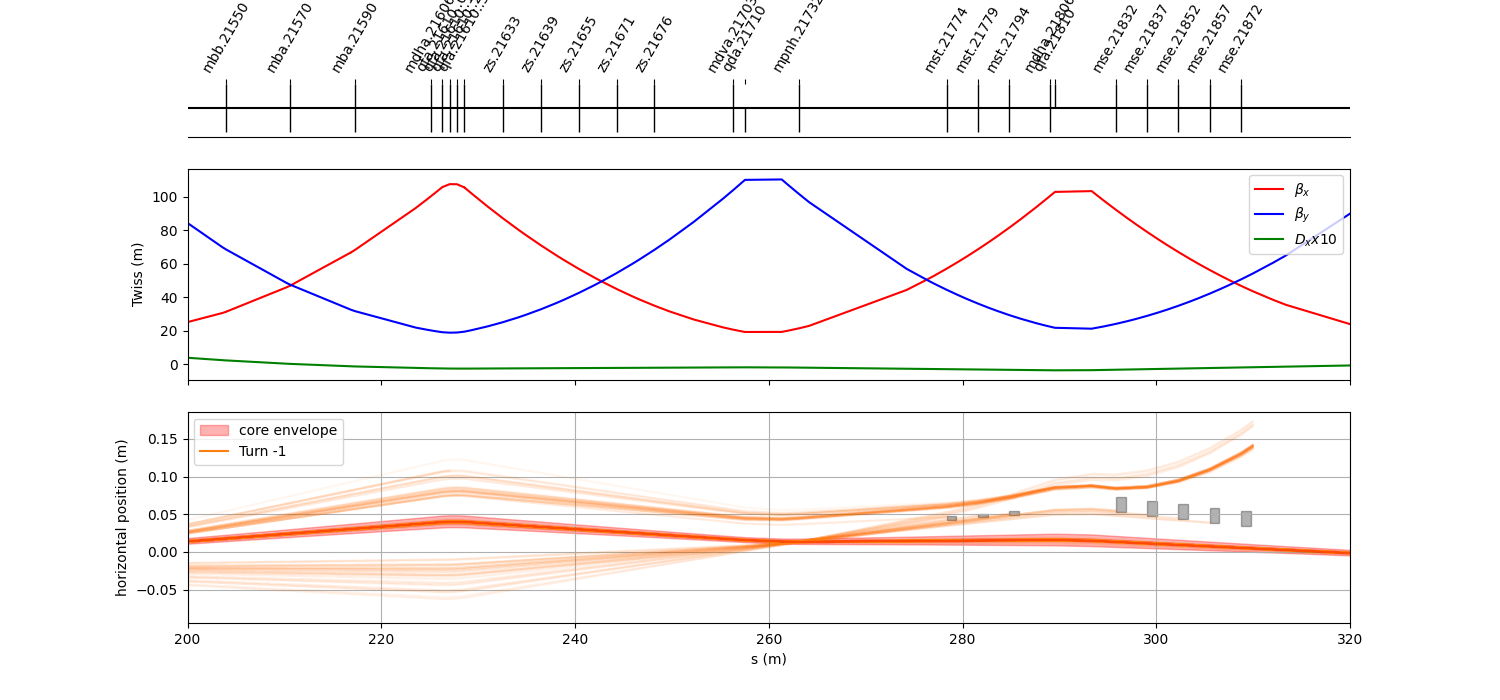

In [392]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlim(200, 320)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
   
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 1

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend()

## phase space at the crystal

Text(0, 0.5, "$x'$ (mrad)")

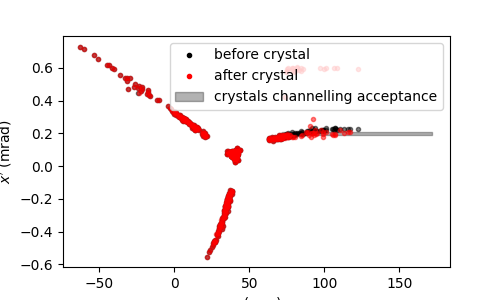

In [393]:
row_before_crystal = tw_lss2_df.loc['extraction.crystal.up']
row_after_crystal = tw_lss2_df.loc['extraction.crystal.dn']

fig, ax = plt.subplots(1, 1, figsize=(5,3))

ax.plot(row_before_crystal['monitors'].x*1e3, row_before_crystal['monitors'].px*1e3, 'k.', alpha = 0.5)
ax.plot(row_after_crystal['monitors'].x*1e3, row_after_crystal['monitors'].px*1e3, 'r.', alpha = 0.5)
ax.plot()

ax.plot([], [], 'k.', label='before crystal')
ax.plot([], [], 'r.', label='after crystal')
ax.fill_between([crystal.jaw*1e3, crystal.jaw*1e3 + crystal.width*1e3], [crystal.tilt*1e3 - 10e-3]*2, [crystal.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
ax.legend()

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")



In [394]:
row = tw_lss2_df.loc['tpst.21760_entry']


#ax.plot(row['monitors'].x*1e3, row['monitors'].px*1e3, 'b.', alpha = 0.5, label = 'before TPST')


In [395]:
crystal.critical_angle

In [396]:
tab = line.get_table()

In [397]:
crystal.jaw

np.float64(0.072)